# Mathematische Grundlagen für Differentialgleichungen

Begleitendes Notebook zu *Angew.Mathe.0MathematischeGrundlagen*: partielle Integration, Integration durch Substitution, Partialbruchzerlegung, Taylorpolynome, komplexe Zahlen, Eigenwerte und lineare Dynamik.

## Warum sind diese Themen für Differentialgleichungen wichtig?

### Kapitel 1-4: Rechenwerkzeuge

- **Partielle Integration:** Hilft bei Lösungsansätzen und auftretenden Integralen, zum Beispiel in Variations- oder Fourier-Verfahren.
- **Integration durch Substitution:** Wird beim Umformen von Integralen und besonders bei der Variablentrennung verwendet.
- **Partialbruchzerlegung:** Ermöglicht nach einer Variablentrennung die Integration rationaler Funktionen.
- **Taylorpolynome:** Bilden die Grundlage für lokale Näherungen, Fehlerabschätzungen und numerische Verfahren wie Euler oder Runge-Kutta.

### Kapitel 5-8: Lineare Dynamik

Diese Kapitel liefern die Werkzeuge zur Untersuchung linearer Differentialgleichungssysteme $z'(t)=Az(t)$:

- **Komplexe Zahlen und Euler-Formel:** Komplexe Eigenwerte führen auf Terme wie $e^{(\alpha+i\beta)t}$. Sie erklären Schwingungen und spiralförmige Bewegungen.
- **Eigenwerte, Eigenvektoren und Diagonalisierung:** Eigenvektoren entkoppeln das System in besonders einfache Richtungen; in diesen entwickelt sich jede Komponente wie $e^{\lambda t}$.
- **Eigenrichtungen in dynamischen Systemen:** Das Vorzeichen eines reellen Eigenwerts zeigt, ob eine Lösung entlang der zugehörigen Eigenrichtung wächst oder abklingt.
- **Eigenwerte und Phasenporträts:** Aus den Eigenwerten lässt sich die Stabilität eines Gleichgewichtspunkts und die Form der Trajektorien im Zustandsraum ablesen.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`, `ipywidgets`
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karkessler/dhbw-mathe3/blob/main/notebooks/differentialgleichungen/00_mathematische_grundlagen.ipynb)

In [46]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Partielle Integration

Wir berechnen $\int x^2e^x\,dx$ symbolisch und prüfen das Ergebnis durch Ableiten.

In [47]:
x = sp.symbols('x', real=True)
f = x**2 * sp.exp(x)
F = sp.integrate(f, x)
kontrolle = sp.simplify(sp.diff(F, x) - f)
print('Stammfunktion:')
display(F)
print('Ableitung minus Integrand =', kontrolle)
assert kontrolle == 0

Stammfunktion:


Ableitung minus Integrand = 0


Die tabellarische partielle Integration liefert $e^x(x^2-2x+2)+C$. SymPy schreibt denselben Ausdruck gegebenenfalls faktorisiert.

## 2. Integration durch Substitution

Bei der Substitution wird eine innere Funktion als neue Variable gewählt. Für $\int 2x\cos(x^2)\,dx$ setzen wir $u=x^2$; dann ist $du=2x\,dx$ und das Integral wird zu $\int\cos(u)\,du=\sin(u)+C$. Nach dem Rückeinsetzen ergibt sich $\sin(x^2)+C$.

Die beiden Flächenplots zeigen dieselbe Fläche in zwei Koordinaten: links den ursprünglichen Integranden als Funktion von $x$, rechts den transformierten Integranden $\cos(u)$ als Funktion der neuen Variablen $u$. Für die Grenzen $0\leq x\leq\sqrt{\pi/2}$ beziehungsweise $0\leq u\leq\pi/2$ stimmen die Flächeninhalte überein.

Stammfunktion:


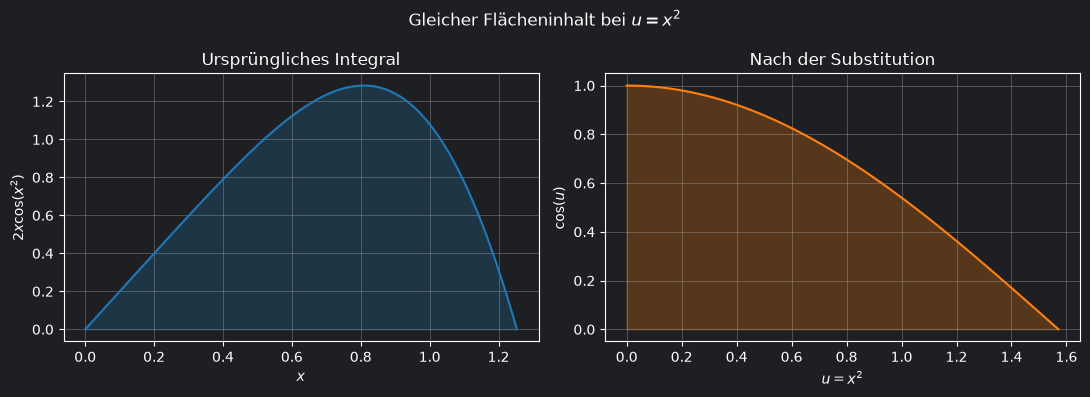

Fläche in x-Koordinaten: 0.999993189320339
Fläche in u-Koordinaten: 0.9999987084452265


In [48]:
u = sp.symbols('u', real=True)
integrand_sub = 2 * x * sp.cos(x**2)
F_sub = sp.integrate(integrand_sub, x)
print('Stammfunktion:')
display(F_sub)
assert sp.simplify(sp.diff(F_sub, x) - integrand_sub) == 0

upper_x = np.sqrt(np.pi / 2)
x_values = np.linspace(0, upper_x, 400)
u_values = np.linspace(0, np.pi / 2, 400)
values_x = 2 * x_values * np.cos(x_values**2)
values_u = np.cos(u_values)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_values, values_x, color='#1f77b4')
axes[0].fill_between(x_values, values_x, alpha=0.25, color='#1f77b4')
axes[0].set(xlabel='$x$', ylabel=r'$2x\cos(x^2)$', title='Ursprüngliches Integral')
axes[1].plot(u_values, values_u, color='#ff7f0e')
axes[1].fill_between(u_values, values_u, alpha=0.25, color='#ff7f0e')
axes[1].set(xlabel='$u=x^2$', ylabel=r'$\cos(u)$', title='Nach der Substitution')
fig.suptitle('Gleicher Flächeninhalt bei $u=x^2$')
plt.tight_layout()
plt.show()
trapezregel = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
print('Fläche in x-Koordinaten:', trapezregel(values_x, x_values))
print('Fläche in u-Koordinaten:', trapezregel(values_u, u_values))

## 3. Partialbruchzerlegung

Ein gebrochenrationaler Integrand lässt sich oft in einfachere Brüche zerlegen. Für
$$\frac{2x+3}{(x+1)(x+2)}=\frac{1}{x+1}+\frac{1}{x+2}$$
können die beiden Summanden einzeln integriert werden. Auf einem Intervall ohne Polstellen, zum Beispiel für $x>-1$, ist daher eine Stammfunktion $\ln(x+1)+\ln(x+2)+C$.

Im Plot wird sichtbar, dass die Summe der beiden einfachen Brüche wieder den ursprünglichen Integranden ergibt. Die gestrichelten Geraden bei $x=-2$ und $x=-1$ markieren die Polstellen; dort ist die Funktion nicht definiert und Integrationsintervalle dürfen diese Stellen nicht überschreiten.

Partialbruchzerlegung:


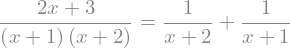

Stammfunktion auf x > -1:


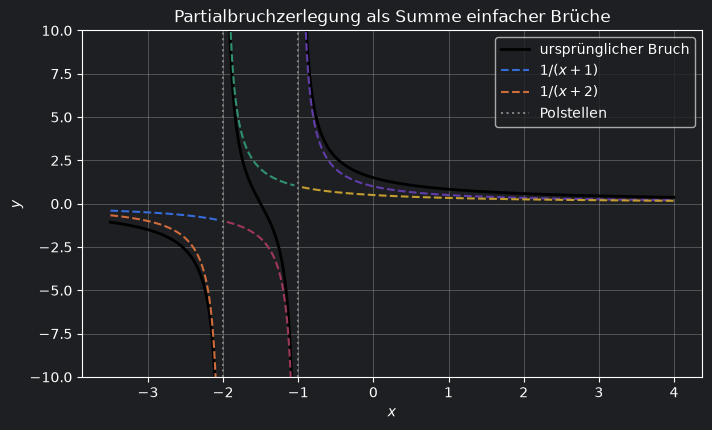

In [49]:
rational = (2 * x + 3) / ((x + 1) * (x + 2))
partial = sp.apart(rational, x)
F_rational = sp.integrate(partial, x)
print('Partialbruchzerlegung:')
display(sp.Eq(rational, partial, evaluate=False))
print('Stammfunktion auf x > -1:')
display(F_rational)
assert sp.simplify(rational - partial) == 0
assert sp.simplify(sp.diff(F_rational, x) - rational) == 0

rational_fn = sp.lambdify(x, rational, 'numpy')
part_1_fn = sp.lambdify(x, 1 / (x + 1), 'numpy')
part_2_fn = sp.lambdify(x, 1 / (x + 2), 'numpy')
intervals = [(-3.5, -2.05), (-1.95, -1.05), (-0.95, 4)]
for index, (start, stop) in enumerate(intervals):
    values = np.linspace(start, stop, 300)
    plt.plot(values, rational_fn(values), color='black', linewidth=2,
             label='ursprünglicher Bruch' if index == 0 else None)
    plt.plot(values, part_1_fn(values), '--', label='$1/(x+1)$' if index == 0 else None)
    plt.plot(values, part_2_fn(values), '--', label='$1/(x+2)$' if index == 0 else None)
plt.axvline(-2, color='gray', linestyle=':', label='Polstellen')
plt.axvline(-1, color='gray', linestyle=':')
plt.ylim(-10, 10)
plt.xlabel('$x$'); plt.ylabel('$y$')
plt.title('Partialbruchzerlegung als Summe einfacher Brüche')
plt.legend()
plt.show()

## 4. Taylorpolynome und Näherungsfehler

Für $e^x$ vergleichen wir Taylorpolynome verschiedener Ordnung auf $[-1,1]$.

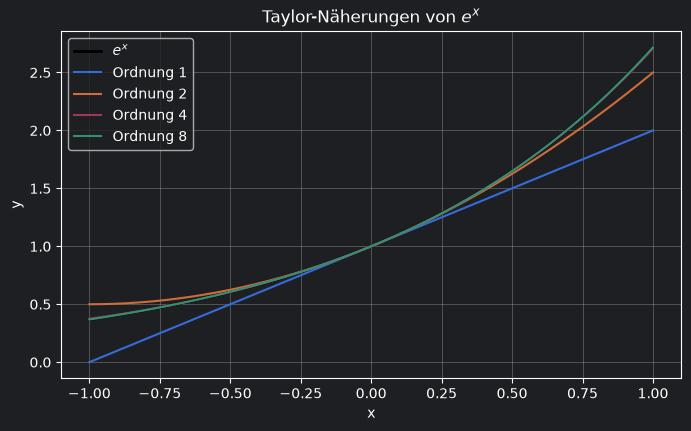

n=1: Näherung=1.100000000000, Fehler=5.171e-03
n=2: Näherung=1.105000000000, Fehler=1.709e-04
n=4: Näherung=1.105170833333, Fehler=8.474e-08
n=8: Näherung=1.105170918076, Fehler=3.109e-15


In [50]:
def taylor_exp(values, order):
    return sum(values**k / sp.factorial(k) for k in range(order + 1))

grid = np.linspace(-1, 1, 400)
plt.plot(grid, np.exp(grid), color='black', linewidth=2, label='$e^x$')
for n in (1, 2, 4, 8):
    approx = np.array(taylor_exp(grid, n), dtype=float)
    plt.plot(grid, approx, label=f'Ordnung {n}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Taylor-Näherungen von $e^x$');
plt.show()

for n in (1, 2, 4, 8):
    value = float(taylor_exp(0.1, n))
    print(f'n={n}: Näherung={value:.12f}, Fehler={abs(np.exp(0.1)-value):.3e}')

## 5. Komplexe Zahlen und die Euler-Formel

Eine komplexe Zahl $z=a+bi$ lässt sich als Punkt $(a,b)$ in der komplexen Ebene auffassen: $a=Re(z)$ ist der Realteil und $b=Im(z)$ der Imaginärteil. Besonders anschaulich ist die Exponentialfunktion auf der imaginären Achse. Die Euler-Formel
$$e^{iθ}=cos(θ)+i sin(θ)$$
besagt, dass $e^{iθ}$ beim Verändern von $θ$ den Einheitskreis durchläuft. Real- und Imaginärteil sind also genau Kosinus und Sinus.

Für jeden reellen Winkel $φ$ hat dieser Punkt den Abstand $1$ vom Ursprung:
$$|e^{iφ}|=|cos(φ)+i sin(φ)|$$
$$=(cos^2(φ)+sin^2(φ))^{1/2}$$
$$=1.$$
Der Faktor $e^{iφ}$ verändert also nur die Richtung, nicht den Abstand zum Ursprung. Er beschreibt eine reine Rotation auf dem Einheitskreis.

Für Differentialgleichungen ist die allgemeinere Form
$$e^{(α+iβ)t}=e^{αt}(cos(βt)+i sin(βt))$$
wichtig. Sie folgt aus der Exponentialregel und der Euler-Formel:
$$e^{(α+iβ)t}=e^{αt+iβt}$$
$$=e^{αt} e^{iβt}$$
$$=e^{αt}(cos(βt)+i sin(βt)).$$

Der Faktor $e^{iβt}$ sorgt für die Rotation. Sein Betrag ist stets $1$:
$$|cos(βt)+i sin(βt)|=1.$$
Der Abstand von $z(t)=e^{(α+iβ)t}$ zum Ursprung ist deshalb
$$|z(t)|=|e^{αt}(cos(βt)+i sin(βt))|$$
$$=e^{αt}.$$

Für den Plot gilt $α=-0{,}12$ und $β=1$:
$$z(t)=e^{(-0{,}12+i)t}=e^{-0{,}12t}(cos(t)+i sin(t)).$$
Da $-0{,}12<0$ gilt,
$$e^{-0{,}12t} → 0  für  t → ∞.$$
Der Radius wird also beim Drehen immer kleiner; die Kurve ist eine Spirale zum Ursprung. Allgemein entsteht bei $α<0$ eine Spirale zum Ursprung, bei $α>0$ eine Spirale nach außen. Der Realteil $e^{αt}cos(βt)$ ist eine gedämpfte beziehungsweise anwachsende Schwingung; $β$ bestimmt ihre Kreisfrequenz.

Euler-Formel:


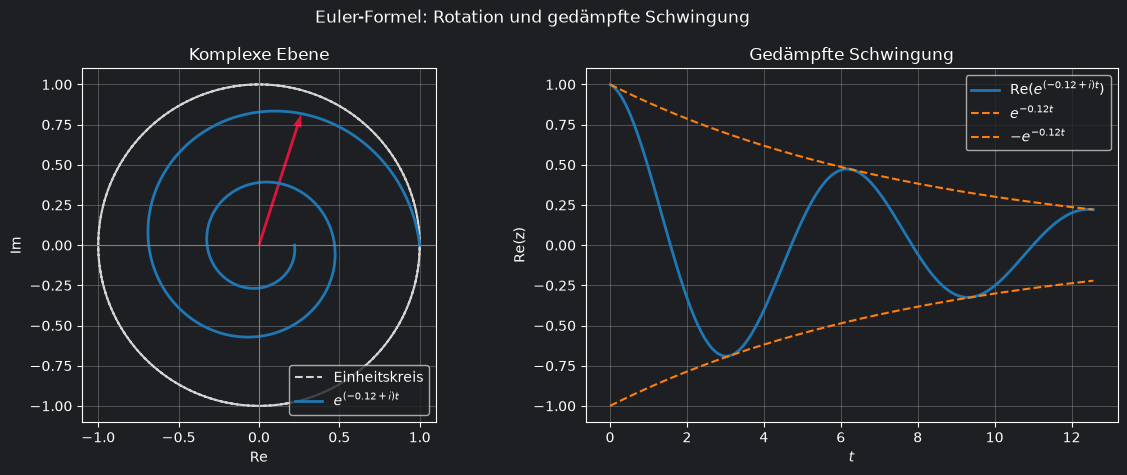

In [51]:
theta = sp.symbols('theta', real=True)
euler_difference = sp.simplify(
    sp.expand_complex(sp.exp(sp.I * theta)) - (sp.cos(theta) + sp.I * sp.sin(theta))
)
print('Euler-Formel:')
display(sp.Eq(sp.exp(sp.I * theta), sp.cos(theta) + sp.I * sp.sin(theta), evaluate=False))
assert euler_difference == 0

alpha, beta = -0.12, 1.0
t = np.linspace(0, 4 * np.pi, 800)
z = np.exp((alpha + 1j * beta) * t)
envelope = np.exp(alpha * t)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(np.cos(t), np.sin(t), '--', color='lightgray', label='Einheitskreis')
axes[0].plot(z.real, z.imag, color='#1f77b4', linewidth=2,
             label='$e^{(-0.12+i)t}$')
point = 80
axes[0].quiver(0, 0, z[point].real, z[point].imag, angles='xy', scale_units='xy',
               scale=1, color='crimson', width=0.008)
axes[0].axhline(0, color='gray', linewidth=0.8); axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set(xlabel='Re', ylabel='Im', title='Komplexe Ebene')
axes[0].set_aspect('equal'); axes[0].legend()

axes[1].plot(t, z.real, color='#1f77b4', linewidth=2,
             label=r'$\operatorname{Re}(e^{(-0.12+i)t})$')
axes[1].plot(t, envelope, '--', color='#ff7f0e', label='$e^{-0.12t}$')
axes[1].plot(t, -envelope, '--', color='#ff7f0e', label='$-e^{-0.12t}$')
axes[1].set(xlabel='$t$', ylabel='Re(z)', title='Gedämpfte Schwingung')
axes[1].legend()
fig.suptitle('Euler-Formel: Rotation und gedämpfte Schwingung')
plt.tight_layout()
plt.show()

### Interaktive Euler-Formel

Mit den Reglern kann der Realteil $\alpha$ und die Kreisfrequenz $\beta$ in $e^{(\alpha+i\beta)t}$ verändert werden. Links ist die Bewegung in der komplexen Ebene, rechts der Realteil als Funktion der Zeit zu sehen.

interactive(children=(FloatSlider(value=-0.12, continuous_update=False, description='$\\alpha$', max=0.2, min=…

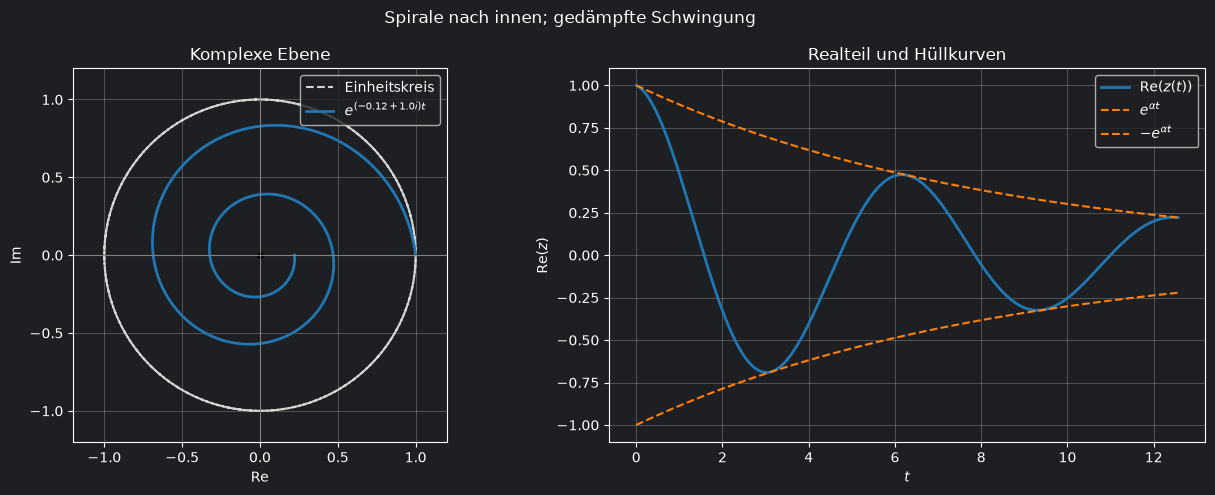

In [52]:
import ipywidgets as widgets


def zeichne_euler_formel(realteil=-0.12, kreisfrequenz=1.0):
    zeit = np.linspace(0, 4 * np.pi, 800)
    komplexe_loesung = np.exp((realteil + 1j * kreisfrequenz) * zeit)
    huellkurve = np.exp(realteil * zeit)

    if realteil < 0:
        beschreibung = 'Spirale nach innen; gedämpfte Schwingung'
    elif realteil > 0:
        beschreibung = 'Spirale nach außen; anwachsende Schwingung'
    else:
        beschreibung = 'Kreisbahn; ungedämpfte Schwingung'

    abbildung, achsen = plt.subplots(1, 2, figsize=(13, 5))
    radius_max = max(1.2, 1.1 * np.max(np.abs(komplexe_loesung)))

    achsen[0].plot(np.cos(zeit), np.sin(zeit), '--', color='lightgray', label='Einheitskreis')
    achsen[0].plot(komplexe_loesung.real, komplexe_loesung.imag, color='#1f77b4', linewidth=2,
                   label=rf'$e^{{({realteil:.2f}+{kreisfrequenz:.1f}i)t}}$')
    achsen[0].plot(0, 0, 'ko', ms=4)
    achsen[0].axhline(0, color='gray', linewidth=0.8)
    achsen[0].axvline(0, color='gray', linewidth=0.8)
    achsen[0].set(xlim=(-radius_max, radius_max), ylim=(-radius_max, radius_max),
                  xlabel='Re', ylabel='Im', title='Komplexe Ebene', aspect='equal')
    achsen[0].legend()

    achsen[1].plot(zeit, komplexe_loesung.real, color='#1f77b4', linewidth=2,
                   label=r'$\operatorname{Re}(z(t))$')
    achsen[1].plot(zeit, huellkurve, '--', color='#ff7f0e', label=r'$e^{\alpha t}$')
    achsen[1].plot(zeit, -huellkurve, '--', color='#ff7f0e', label=r'$-e^{\alpha t}$')
    achsen[1].set(xlabel='$t$', ylabel='Re$(z)$', title='Realteil und Hüllkurven')
    achsen[1].legend()
    abbildung.suptitle(beschreibung)
    plt.tight_layout()
    plt.show()


widgets.interact(
    zeichne_euler_formel,
    realteil=widgets.FloatSlider(value=-0.12, min=-0.2, max=0.2, step=0.02,
                                 description=r'$\alpha$', continuous_update=False),
    kreisfrequenz=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1,
                                      description=r'$\beta$', continuous_update=False),
);
zeichne_euler_formel()

## 6. Eigenwerte, Eigenvektoren und Diagonalisierung

Für die Matrix $A=\begin{pmatrix}4&1\cr 2&3\end{pmatrix}$ bestimmt das Notebook zunächst die Eigenwerte und zugehörigen Eigenvektoren. Die Eigenwerte $\lambda_1=2$ und $\lambda_2=5$ beschreiben die Streckung in den jeweiligen Eigenrichtungen. Die zugehörigen Eigenvektoren werden als Spalten zur Matrix $P$ zusammengefasst; die Eigenwerte stehen auf der Diagonalen von $D$.

Eine Matrix ist kein Vektor und kann daher nicht als einzelner Pfeil gezeichnet werden. Ihre Wirkung wird im linken Diagramm sichtbar: Die Standardbasisvektoren $e_1$ und $e_2$ sowie das Einheitsquadrat werden durch $A$ auf die Vektoren $A e_1$, $A e_2$ und ein Parallelogramm abgebildet.

Für einen Eigenvektor $x$ gilt
$$A\cdot x=\lambda x.$$
Die beiden rechten Diagramme zeichnen für jeden Eigenwert den normierten Eigenvektor $x$ (blau) und sein Bild $A x=\lambda x$ (orange). Beide Pfeile liegen auf derselben Geraden: Die Matrix verändert bei einem Eigenvektor also nicht die Richtung, sondern nur seine Länge. Für $\lambda=2$ wird der Vektor doppelt so lang, für $\lambda=5$ fünfmal so lang.

Damit lässt sich $A$ als $A=PDP^{-1}$ schreiben. Diese Diagonalisierung bedeutet einen Koordinatenwechsel: In den durch die Eigenvektoren gegebenen Koordinaten wirkt $A$ besonders einfach, weil jede Koordinate nur mit ihrem Eigenwert multipliziert wird. Die Codezelle gibt die Eigenwertdaten sowie $P$ und $D$ aus, zeichnet die Matrixwirkung und die Eigenvektoren mit ihren Bildern und prüft abschließend durch $A-PDP^{-1}=0$, dass die Zerlegung korrekt ist.

Eigenwerte und zugehörige Eigenvektoren:
Eigenwert λ_1 = 2
Zugehöriger Eigenvektor v_1:


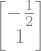

Eigenwert λ_2 = 5
Zugehöriger Eigenvektor v_2:


P = [v_1  v_2]: Die Spalten von P sind die Eigenvektoren.


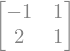

D = diag(λ_1, λ_2): Auf der Diagonalen stehen die Eigenwerte.


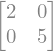

Kontrolle A - P D P^{-1} =


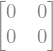

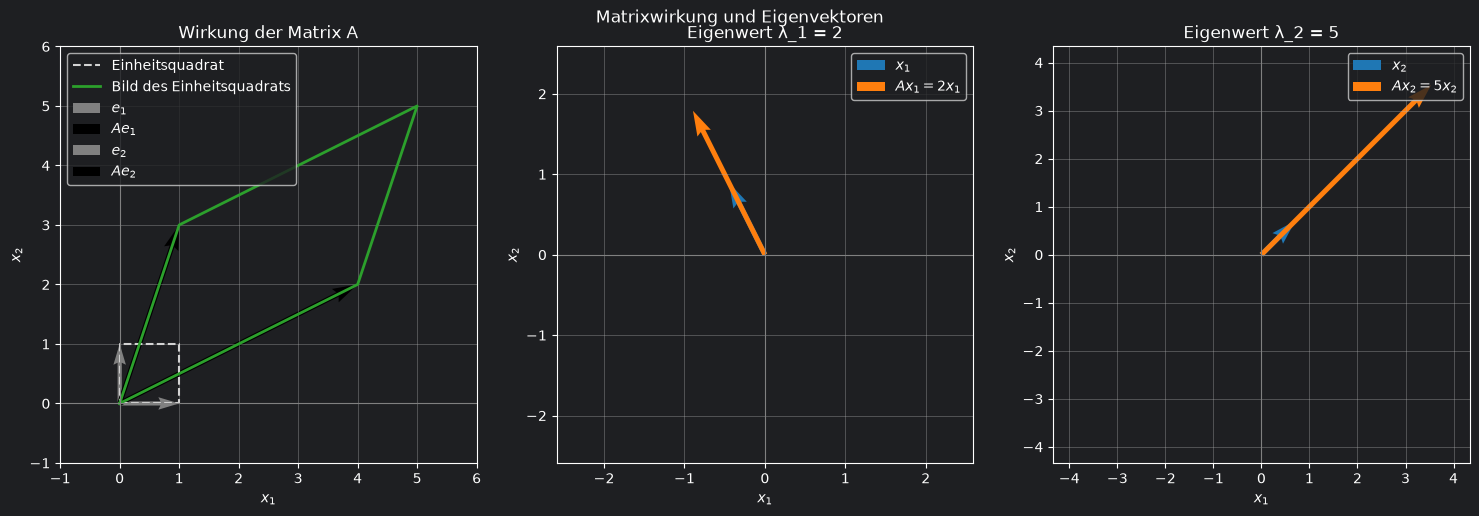

In [53]:
A = sp.Matrix([[4, 1], [2, 3]])
eigen = A.eigenvects()
print('Eigenwerte und zugehörige Eigenvektoren:')
for index, (eigenvalue, _, eigenvectors) in enumerate(eigen, start=1):
    print(f'Eigenwert λ_{index} = {eigenvalue}')
    print(f'Zugehöriger Eigenvektor v_{index}:')
    display(eigenvectors[0])

P, D = A.diagonalize()
print('P = [v_1  v_2]: Die Spalten von P sind die Eigenvektoren.')
display(P)
print('D = diag(λ_1, λ_2): Auf der Diagonalen stehen die Eigenwerte.')
display(D)
print('Kontrolle A - P D P^{-1} =')
display(sp.simplify(A - P * D * P.inv()))
assert A == P * D * P.inv()

A_numeric = np.array(A, dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

matrix_axis = axes[0]
unit_square = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]], dtype=float)
transformed_square = A_numeric @ unit_square
matrix_axis.plot(unit_square[0], unit_square[1], '--', color='lightgray',
                 label='Einheitsquadrat')
matrix_axis.plot(transformed_square[0], transformed_square[1], color='#2ca02c',
                 linewidth=2, label='Bild des Einheitsquadrats')
for index, vector in enumerate(np.eye(2), start=1):
    image = A_numeric @ vector
    matrix_axis.quiver(0, 0, vector[0], vector[1], angles='xy', scale_units='xy',
                       scale=1, color='gray', width=0.01, label=f'$e_{index}$')
    matrix_axis.quiver(0, 0, image[0], image[1], angles='xy', scale_units='xy',
                       scale=1, width=0.012, label=f'$A e_{index}$')
matrix_axis.axhline(0, color='gray', linewidth=0.8)
matrix_axis.axvline(0, color='gray', linewidth=0.8)
matrix_axis.set(xlim=(-1, 6), ylim=(-1, 6), xlabel='$x_1$', ylabel='$x_2$',
                title='Wirkung der Matrix A')
matrix_axis.set_aspect('equal')
matrix_axis.legend(loc='upper left')

eigenvalues = list(D.diagonal())
for index, (axis, eigenvalue) in enumerate(zip(axes[1:], eigenvalues), start=1):
    eigenvector = np.array(P[:, index - 1], dtype=float).reshape(2)
    eigenvector /= np.linalg.norm(eigenvector)
    image = float(eigenvalue) * eigenvector
    limit = np.max(np.abs(image)) + 0.8

    axis.axhline(0, color='gray', linewidth=0.8)
    axis.axvline(0, color='gray', linewidth=0.8)
    axis.quiver(0, 0, eigenvector[0], eigenvector[1], angles='xy', scale_units='xy',
                scale=1, color='#1f77b4', width=0.012, label=f'$x_{index}$')
    axis.quiver(0, 0, image[0], image[1], angles='xy', scale_units='xy',
                scale=1, color='#ff7f0e', width=0.012,
                label=f'$A x_{index} = {eigenvalue} x_{index}$')
    axis.set(xlim=(-limit, limit), ylim=(-limit, limit), xlabel='$x_1$', ylabel='$x_2$',
             title=f'Eigenwert λ_{index} = {eigenvalue}')
    axis.set_aspect('equal')
    axis.legend()

fig.suptitle('Matrixwirkung und Eigenvektoren')
plt.tight_layout()
plt.show()

### Interaktive Eigenwerte und Eigenvektoren

Die Regler bestimmen die Einträge $a$, $b$, $c$ und $d$ der Matrix. Zu Beginn ist dieselbe Matrix wie in der ursprünglichen Aufgabe eingestellt: $A_{11}=4$, $A_{12}=1$, $A_{21}=2$, $A_{22}=3$. Die Werte für $b$ und $c$ sind auf nichtnegative Zahlen beschränkt, damit die Eigenwerte reell bleiben. Die Grafik zeichnet für jede Eigenrichtung den normierten Eigenvektor $v$ (blau) und sein Bild $Av=\lambda v$ (orange).

interactive(children=(FloatSlider(value=4.0, continuous_update=False, description='$a$', max=5.0, min=-5.0, st…

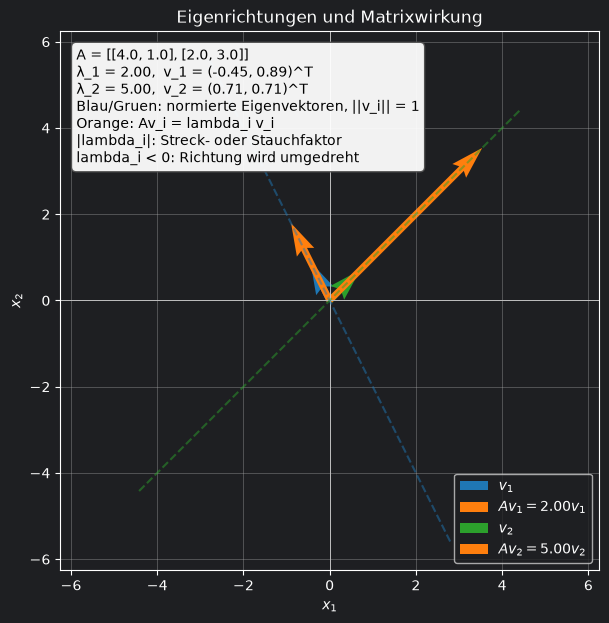

In [54]:
import ipywidgets as widgets


def zeichne_eigenwerte_und_eigenvektoren(a=4.0, b=1.0, c=2.0, d=3.0):
    matrix_interaktiv = np.array([[a, b], [c, d]])
    eigenwerte_interaktiv, eigenvektoren_interaktiv = np.linalg.eig(matrix_interaktiv)
    sortierung = np.argsort(eigenwerte_interaktiv)
    eigenwerte_interaktiv = np.real_if_close(eigenwerte_interaktiv[sortierung])
    eigenvektoren_interaktiv = np.real_if_close(eigenvektoren_interaktiv[:, sortierung])

    abbildung, achse = plt.subplots(figsize=(8, 7))
    groesster_eigenwert = np.max(np.abs(eigenwerte_interaktiv))
    grenze = max(1.5, 1.25 * groesster_eigenwert)
    farben = ['#1f77b4', '#2ca02c']

    achse.axhline(0, color='0.75', lw=0.7)
    achse.axvline(0, color='0.75', lw=0.7)
    for index, (eigenwert, farbe) in enumerate(zip(eigenwerte_interaktiv, farben), start=1):
        eigenvektor = eigenvektoren_interaktiv[:, index - 1]
        bildvektor = eigenwert * eigenvektor
        achse.quiver(0, 0, eigenvektor[0], eigenvektor[1], angles='xy', scale_units='xy',
                     scale=1, color=farbe, width=0.012, label=rf'$v_{index}$')
        achse.quiver(0, 0, bildvektor[0], bildvektor[1], angles='xy', scale_units='xy',
                     scale=1, color='#ff7f0e', width=0.012,
                     label=rf'$Av_{index}={eigenwert:.2f}v_{index}$')
        achse.plot([-grenze * eigenvektor[0], grenze * eigenvektor[0]],
                   [-grenze * eigenvektor[1], grenze * eigenvektor[1]], '--', color=farbe,
                   alpha=0.5)

    matrix_text = f'A = [[{a:.1f}, {b:.1f}], [{c:.1f}, {d:.1f}]]'
    eigendaten_text = chr(10).join(
        f'λ_{index} = {eigenwert:.2f},  v_{index} = ({eigenvektor[0]:.2f}, {eigenvektor[1]:.2f})^T'
        for index, (eigenwert, eigenvektor) in enumerate(
            zip(eigenwerte_interaktiv, eigenvektoren_interaktiv.T), start=1
        )
    )
    hinweis_text = chr(10).join([
        'Blau/Gruen: normierte Eigenvektoren, ||v_i|| = 1',
        'Orange: Av_i = lambda_i v_i',
        '|lambda_i|: Streck- oder Stauchfaktor',
        'lambda_i < 0: Richtung wird umgedreht',
    ])
    achse.text(0.03, 0.97, matrix_text + chr(10) + eigendaten_text + chr(10) + hinweis_text,
               transform=achse.transAxes, va='top', color='black',
               bbox={'boxstyle': 'round,pad=0.35', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    achse.set(xlim=(-grenze, grenze), ylim=(-grenze, grenze), aspect='equal',
              xlabel='$x_1$', ylabel='$x_2$', title='Eigenrichtungen und Matrixwirkung')
    achse.legend(loc='lower right')
    plt.show()


widgets.interact(
    zeichne_eigenwerte_und_eigenvektoren,
    a=widgets.FloatSlider(value=4.0, min=-5.0, max=5.0, step=0.5,
                          description='$a$', continuous_update=False),
    b=widgets.FloatSlider(value=1.0, min=0.0, max=5.0, step=0.5,
                          description='$b$', continuous_update=False),
    c=widgets.FloatSlider(value=2.0, min=0.0, max=5.0, step=0.5,
                          description='$c$', continuous_update=False),
    d=widgets.FloatSlider(value=3.0, min=-5.0, max=5.0, step=0.5,
                          description='$d$', continuous_update=False),
);
zeichne_eigenwerte_und_eigenvektoren()

## 7. Eigenrichtungen in einem stabilen dynamischen System

Dieses Kapitel wendet die Eigenwerte und Eigenvektoren aus Kapitel 6 auf eine Differentialgleichung an. In Kapitel 6 beschreibt
$$A x=\lambda x$$
die Wirkung der Matrix auf einen einzelnen Vektor: Ein Eigenvektor behält seine Richtung und wird mit dem Eigenwert $\lambda$ gestreckt. Hier bestimmt die Matrix dagegen die zeitliche Änderung eines Zustands:
$$z'(t)=A_\mathrm{stabil}z(t).$$

Wir betrachten das lineare System mit
$$A_\mathrm{stabil}=\begin{pmatrix}-1&1\cr 0&-2\end{pmatrix}.$$
Seine Eigenwerte sind $-1$ und $-2$. Startet eine Lösung auf einer Eigenrichtung $v$ mit
$$A_\mathrm{stabil}v=\lambda v,$$
dann bleibt sie auf dieser Geraden. Denn mit $z(t)=c(t)v$ folgt
$$c'(t)v=z'(t)=A_\mathrm{stabil}z(t)=c(t)A_\mathrm{stabil}v=c(t)\lambda v,$$
also
$$c'(t)=\lambda c(t)$$
und damit
$$z(t)=e^{\lambda t}v.$$

Da beide Eigenwerte negativ sind, gilt
$$e^{-t}	o0\qquad	ext{und}\qquad e^{-2t}	o0\qquad	ext{für}\quad t	o\infty.$$
Der Nullpunkt ist daher asymptotisch stabil und jede Lösung nähert sich dem Ursprung. Der Anteil in der Eigenrichtung zu $\lambda=-2$ klingt schneller ab als der Anteil zu $\lambda=-1$. Deshalb prägt langfristig die langsamere Eigenrichtung den Verlauf.

Für die Anfangsbedingung $z(0)=(2,1)^T$ zerlegt die Codezelle den Anfangsvektor in diese Eigenrichtungen. Anschließend berechnet sie die Zeitentwicklung jeder Komponente mit $e^{\lambda t}$ und zeichnet $z_1(t)$ und $z_2(t)$.

Eigenwerte: [-1.+0.j -2.+0.j]
Stabil, weil alle Realteile negativ: True


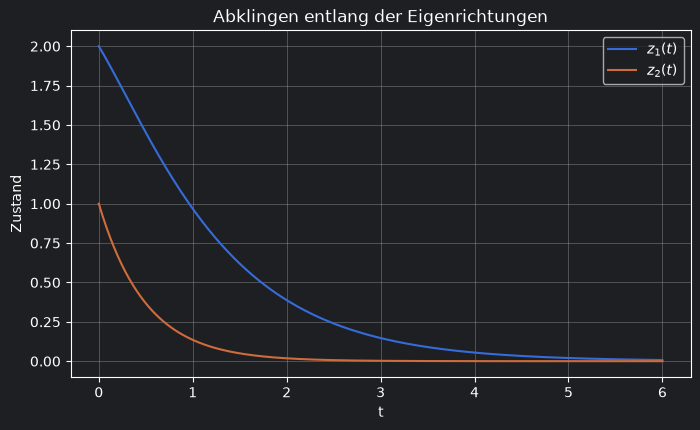

In [55]:
A_stabil = np.array([[-1.0, 1.0], [0.0, -2.0]])
vals, vecs = np.linalg.eig(A_stabil)
print('Eigenwerte:', vals)
print('Stabil, weil alle Realteile negativ:', np.all(np.real(vals) < 0))

t = np.linspace(0, 6, 300)
z0 = np.array([2.0, 1.0])
V = vecs
coeff = np.linalg.solve(V, z0)
traj = np.array([V @ (np.exp(vals * ti) * coeff) for ti in t]).real
plt.plot(t, traj[:, 0], label='$z_1(t)$')
plt.plot(t, traj[:, 1], label='$z_2(t)$')
plt.xlabel('t'); plt.ylabel('Zustand'); plt.legend();
plt.title('Abklingen entlang der Eigenrichtungen'); plt.show()

## 8. Eigenwerte und Phasenporträts linearer Systeme

Für ein zweidimensionales lineares autonomes System
$$z'(t)=Az(t)$$
entscheiden die Eigenwerte von $A$, wie sich Lösungen in der Nähe des Gleichgewichts $z=0$ verhalten. Dabei ist wichtig: Die Eigenwerte beschreiben **die zeitliche Entwicklung** $e^{\lambda t}$, nicht nur die einmalige Matrixwirkung $Az=\lambda z$.

Ein **Phasenporträt** ist ein Zustandsraumdiagramm: Jeder Punkt $(z_1,z_2)$ beschreibt den momentanen Zustand des Systems. Die gezeichneten Kurven heißen Trajektorien und zeigen, wie sich dieser Zustand entwickelt; die Zeit ist nicht als eigene Achse eingezeichnet, sondern durch die Pfeilrichtung enthalten.

### Reelle Eigenwerte

| Eigenwerte | Phasenporträt für große $t$ | Stabilität des Ursprungs |
|---|---|---|
| $\lambda_1<0$, $\lambda_2<0$ | Alle Lösungen laufen zum Ursprung: stabiler Knoten. Entlang einer Eigenrichtung gilt $z(t)=e^{\lambda t}v$; je negativer $\lambda$, desto schneller klingt dieser Anteil ab. | asymptotisch stabil |
| $\lambda_1>0$, $\lambda_2>0$ | Alle Lösungen laufen vom Ursprung weg: instabiler Knoten bzw. Quelle. | instabil |
| $\lambda_1<0<\lambda_2$ | In einer Eigenrichtung laufen Lösungen zum Ursprung, in der anderen vom Ursprung weg: Sattelpunkt. | instabil |

Bei zwei verschiedenen reellen Eigenwerten geben die beiden Eigenvektoren die ausgezeichneten Geraden des Phasenporträts an. Wiederholte reelle Eigenwerte können je nach Zahl der Eigenvektoren einen Sternknoten oder einen uneigentlichen Knoten ergeben; das Vorzeichen entscheidet aber weiterhin über Anziehung oder Abstoßung.

### Komplex konjugierte Eigenwerte

Bei einer reellen $2\cdot2$-Matrix treten nichtreelle Eigenwerte stets als Paar
$$\lambda_{1,2}=\alpha\pm i\beta,\qquad |\beta|>0$$
auf. Die zugehörigen Lösungen enthalten den Faktor
$$e^{(\alpha+i\beta)t}=e^{\alpha t}\bigl(\cos(\beta t)+i\sin(\beta t)\bigr).$$
Der Imaginärteil $\beta$ verursacht also die **Drehung**; sein Betrag bestimmt die Winkelgeschwindigkeit. Das Vorzeichen von $\beta$ legt die Drehrichtung fest, sofern die verwendeten Koordinaten orientiert sind. Der Realteil $\alpha$ bestimmt gleichzeitig, ob der Abstand zum Ursprung wächst oder schrumpft:

Zu nichtreellen Eigenwerten gehören komplexe Eigenvektoren, aber keine reellen Eigenrichtungen. Im reellen Zustandsraum erscheinen deshalb keine ausgezeichneten Geraden, sondern Spiralen oder Kreisbahnen.

| Eigenwerte | Phasenporträt | Stabilität des Ursprungs |
|---|---|---|
| $\alpha<0$, $|\beta|>0$ | Spirale zum Ursprung: stabiler Fokus. | asymptotisch stabil |
| $\alpha>0$, $|\beta|>0$ | Spirale vom Ursprung weg: instabiler Fokus. | instabil |
| $\alpha=0$, $|\beta|>0$ | Geschlossene Bahnen um den Ursprung: Zentrum; es gibt Rotation ohne Zu- oder Abnahme des Abstands. | stabil, aber nicht asymptotisch stabil |

Eigenwerte mit Realteil $0$, insbesondere ein reeller Eigenwert $0$, sind Sonderfälle. Aus den Eigenwerten allein folgt dann keine asymptotische Stabilität; bei nichtlinearen Systemen muss man die höheren Terme untersuchen.

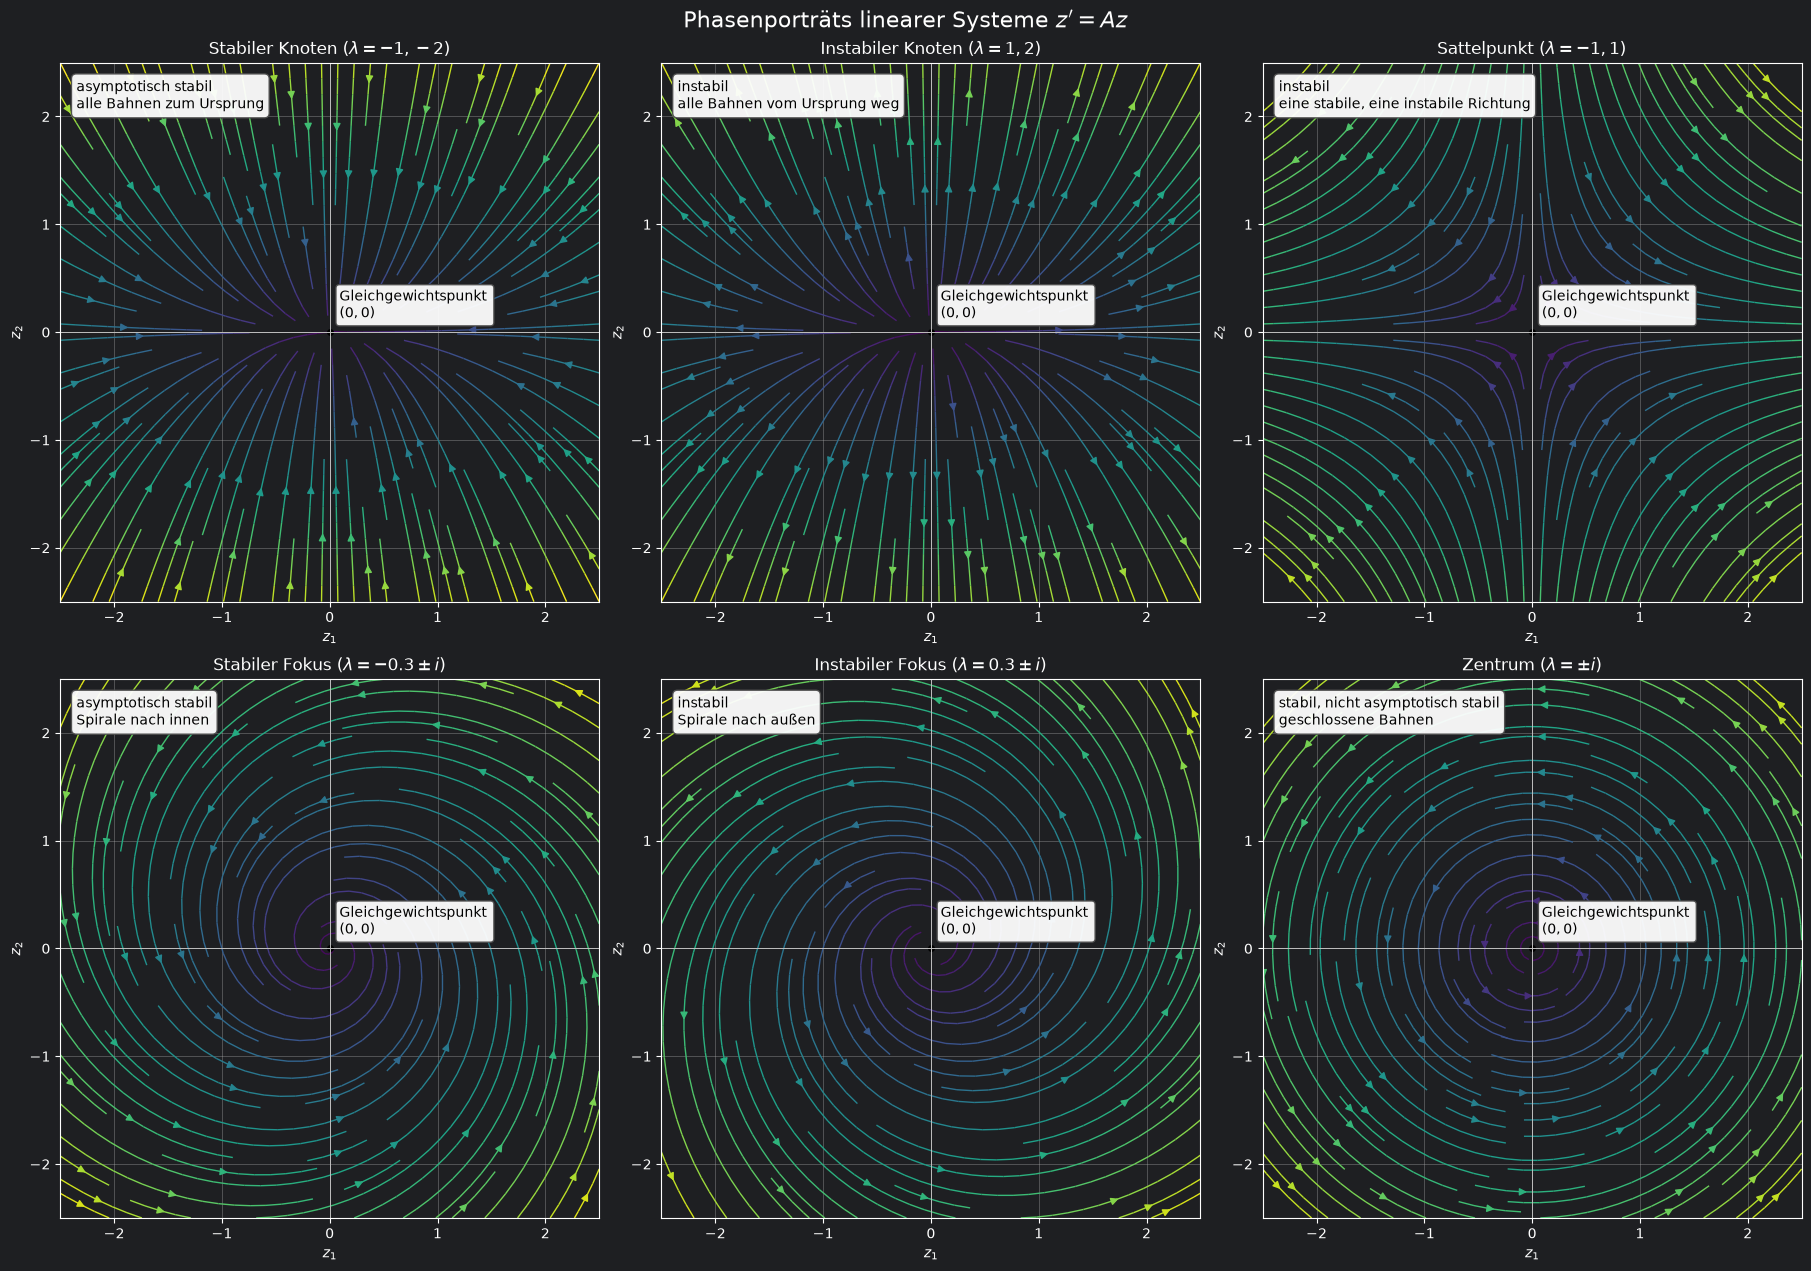

In [56]:
# Phasenporträts: Die Pfeile zeigen die zeitliche Änderung z' = Az.
zeilenumbruch = chr(10)
faelle = [
    (r'Stabiler Knoten ($\lambda=-1,-2$)', np.array([[-1., 0.], [0., -2.]]),
     zeilenumbruch.join(['asymptotisch stabil', 'alle Bahnen zum Ursprung'])),
    (r'Instabiler Knoten ($\lambda=1,2$)', np.array([[1., 0.], [0., 2.]]),
     zeilenumbruch.join(['instabil', 'alle Bahnen vom Ursprung weg'])),
    (r'Sattelpunkt ($\lambda=-1,1$)', np.array([[1., 0.], [0., -1.]]),
     zeilenumbruch.join(['instabil', 'eine stabile, eine instabile Richtung'])),
    (r'Stabiler Fokus ($\lambda=-0.3\pm i$)', np.array([[-0.3, -1.], [1., -0.3]]),
     zeilenumbruch.join(['asymptotisch stabil', 'Spirale nach innen'])),
    (r'Instabiler Fokus ($\lambda=0.3\pm i$)', np.array([[0.3, -1.], [1., 0.3]]),
     zeilenumbruch.join(['instabil', 'Spirale nach außen'])),
    (r'Zentrum ($\lambda=\pm i$)', np.array([[0., -1.], [1., 0.]]),
     zeilenumbruch.join(['stabil, nicht asymptotisch stabil', 'geschlossene Bahnen'])),
]

gitter = np.linspace(-2.5, 2.5, 25)
X, Y = np.meshgrid(gitter, gitter)
fig, axes = plt.subplots(2, 3, figsize=(18, 12.6), constrained_layout=True)

for ax, (titel, A, bemerkung) in zip(axes.flat, faelle):
    U = A[0, 0] * X + A[0, 1] * Y
    V = A[1, 0] * X + A[1, 1] * Y
    geschwindigkeit = np.hypot(U, V)
    ax.streamplot(X, Y, U, V, color=geschwindigkeit, cmap='viridis', density=1.15,
                  linewidth=1, arrowsize=1.1)
    ax.plot(0, 0, 'ko', ms=4)
    ax.annotate('Gleichgewichtspunkt ' + zeilenumbruch + '$(0,0)$', xy=(0, 0), xytext=(7, 7),
                textcoords='offset points', fontsize=10, color='black', ha='left', va='bottom',
                bbox={'boxstyle': 'round,pad=0.25', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    ax.text(0.03, 0.97, bemerkung, transform=ax.transAxes, va='top', fontsize=10, color='black',
            bbox={'boxstyle': 'round,pad=0.35', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    ax.axhline(0, color='0.75', lw=0.7)
    ax.axvline(0, color='0.75', lw=0.7)
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect='equal', title=titel,
           xlabel='$z_1$', ylabel='$z_2$')

fig.suptitle("Phasenporträts linearer Systeme $z'=Az$", fontsize=16)
plt.show()

### Interaktives Phasenporträt eines Fokus

Mit den Reglern lassen sich die Eigenwerte
$$\lambda_{1,2}=\alpha\pm i\beta$$
verändern. Für $|\beta|>0$ bestimmt $\alpha$ die Stabilität: Bei $\alpha<0$ spiralisieren die Bahnen nach innen und es liegt ein stabiler Fokus vor; bei $\alpha>0$ spiralisieren sie nach außen. Der Betrag von $\beta$ bestimmt die Drehgeschwindigkeit.

interactive(children=(FloatSlider(value=-0.3, continuous_update=False, description='$\\alpha$', max=1.5, min=-…

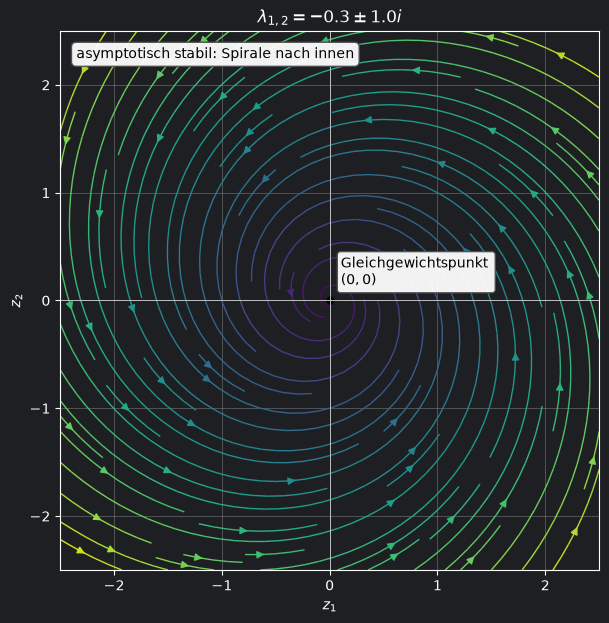

In [57]:
import ipywidgets as widgets


def zeichne_fokus(realteil=-0.3, imaginaerteil=1.0):
    matrix_fokus = np.array([[realteil, -imaginaerteil], [imaginaerteil, realteil]])
    gitter_fokus = np.linspace(-2.5, 2.5, 25)
    x_fokus, y_fokus = np.meshgrid(gitter_fokus, gitter_fokus)
    u_fokus = matrix_fokus[0, 0] * x_fokus + matrix_fokus[0, 1] * y_fokus
    v_fokus = matrix_fokus[1, 0] * x_fokus + matrix_fokus[1, 1] * y_fokus

    if realteil < 0:
        beschreibung = 'asymptotisch stabil: Spirale nach innen'
    elif realteil > 0:
        beschreibung = 'instabil: Spirale nach außen'
    else:
        beschreibung = 'stabil, nicht asymptotisch stabil: Zentrum'

    abbildung, achse = plt.subplots(figsize=(8, 7))
    achse.streamplot(x_fokus, y_fokus, u_fokus, v_fokus,
                     color=np.hypot(u_fokus, v_fokus), cmap='viridis', density=1.2,
                     linewidth=1, arrowsize=1.1)
    achse.plot(0, 0, 'ko', ms=5)
    achse.annotate('Gleichgewichtspunkt ' + chr(10) + '$(0,0)$', xy=(0, 0), xytext=(8, 8),
                   textcoords='offset points', color='black', ha='left', va='bottom',
                   bbox={'boxstyle': 'round,pad=0.25', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    achse.text(0.03, 0.97, beschreibung, transform=achse.transAxes, va='top', color='black',
               bbox={'boxstyle': 'round,pad=0.35', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    achse.axhline(0, color='0.75', lw=0.7)
    achse.axvline(0, color='0.75', lw=0.7)
    achse.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect='equal', xlabel='$z_1$', ylabel='$z_2$',
              title=rf'$\lambda_{{1,2}}={realteil:.1f}\pm {imaginaerteil:.1f}i$')
    plt.show()


widgets.interact(
    zeichne_fokus,
    realteil=widgets.FloatSlider(value=-0.3, min=-1.5, max=1.5, step=0.1,
                                  description=r'$\alpha$', continuous_update=False),
    imaginaerteil=widgets.FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1,
                                      description=r'$\beta$', continuous_update=False),
);
zeichne_fokus()

### Interaktives Phasenporträt mit reellen Eigenwerten

Hier ist die Matrix bereits in der Eigenvektorbasis gegeben:
$$A=\operatorname{diag}(\lambda_1,\lambda_2).$$
Die Regler verändern die beiden reellen Eigenwerte. Zwei negative Eigenwerte ergeben einen stabilen Knoten, zwei positive einen instabilen Knoten und unterschiedliche Vorzeichen einen Sattelpunkt. Ein Eigenwert $0$ ist ein Sonderfall.

interactive(children=(FloatSlider(value=-1.0, continuous_update=False, description='$\\lambda_1$', max=3.0, mi…

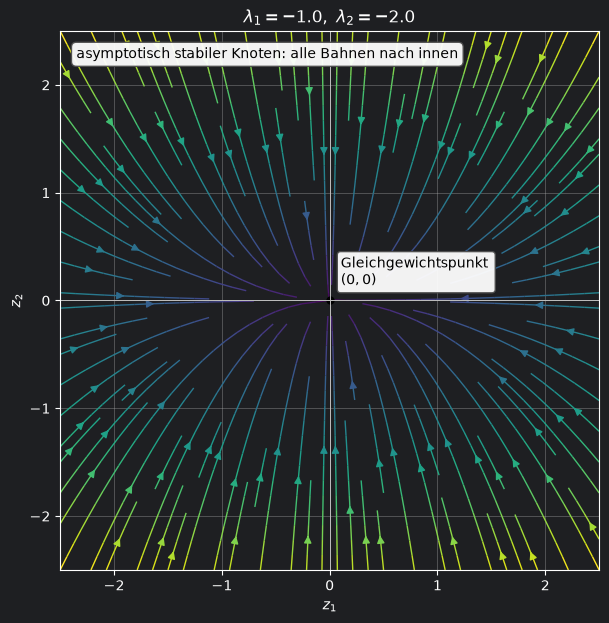

In [58]:
import ipywidgets as widgets


def zeichne_reelle_eigenwerte(eigenwert_1=-1.0, eigenwert_2=-2.0):
    matrix_reell = np.diag([eigenwert_1, eigenwert_2])
    gitter_reell = np.linspace(-2.5, 2.5, 25)
    x_reell, y_reell = np.meshgrid(gitter_reell, gitter_reell)
    u_reell = matrix_reell[0, 0] * x_reell
    v_reell = matrix_reell[1, 1] * y_reell

    if eigenwert_1 == 0 or eigenwert_2 == 0:
        beschreibung = 'Sonderfall: mindestens ein Eigenwert ist 0'
    elif eigenwert_1 < 0 and eigenwert_2 < 0:
        beschreibung = 'asymptotisch stabiler Knoten: alle Bahnen nach innen'
    elif eigenwert_1 > 0 and eigenwert_2 > 0:
        beschreibung = 'instabiler Knoten: alle Bahnen nach außen'
    else:
        beschreibung = 'Sattelpunkt: eine stabile und eine instabile Richtung'

    abbildung, achse = plt.subplots(figsize=(8, 7))
    achse.streamplot(x_reell, y_reell, u_reell, v_reell,
                     color=np.hypot(u_reell, v_reell), cmap='viridis', density=1.2,
                     linewidth=1, arrowsize=1.1)
    achse.plot(0, 0, 'ko', ms=5)
    achse.annotate('Gleichgewichtspunkt ' + chr(10) + '$(0,0)$', xy=(0, 0), xytext=(8, 8),
                   textcoords='offset points', color='black', ha='left', va='bottom',
                   bbox={'boxstyle': 'round,pad=0.25', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    achse.text(0.03, 0.97, beschreibung, transform=achse.transAxes, va='top', color='black',
               bbox={'boxstyle': 'round,pad=0.35', 'fc': 'white', 'alpha': 0.95, 'ec': '0.3'})
    achse.axhline(0, color='0.75', lw=0.7)
    achse.axvline(0, color='0.75', lw=0.7)
    achse.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect='equal', xlabel='$z_1$', ylabel='$z_2$',
              title=rf'$\lambda_1={eigenwert_1:.1f},\ \lambda_2={eigenwert_2:.1f}$')
    plt.show()


widgets.interact(
    zeichne_reelle_eigenwerte,
    eigenwert_1=widgets.FloatSlider(value=-1.0, min=-3.0, max=3.0, step=0.1,
                                    description=r'$\lambda_1$', continuous_update=False),
    eigenwert_2=widgets.FloatSlider(value=-2.0, min=-3.0, max=3.0, step=0.1,
                                    description=r'$\lambda_2$', continuous_update=False),
);
zeichne_reelle_eigenwerte()